In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("pair_smiles.csv")

# --- 1. Приведение числовых колонок ---
numeric_cols = ["QED", "SA", "MW", "logP"]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

In [7]:
# --- 2. Приведение бинарных колонок ---
binary_cols = ["Lipinski", "BRENK", "PAINS", "Glaxo"]

for col in binary_cols:
    df[col] = df[col].astype(bool)

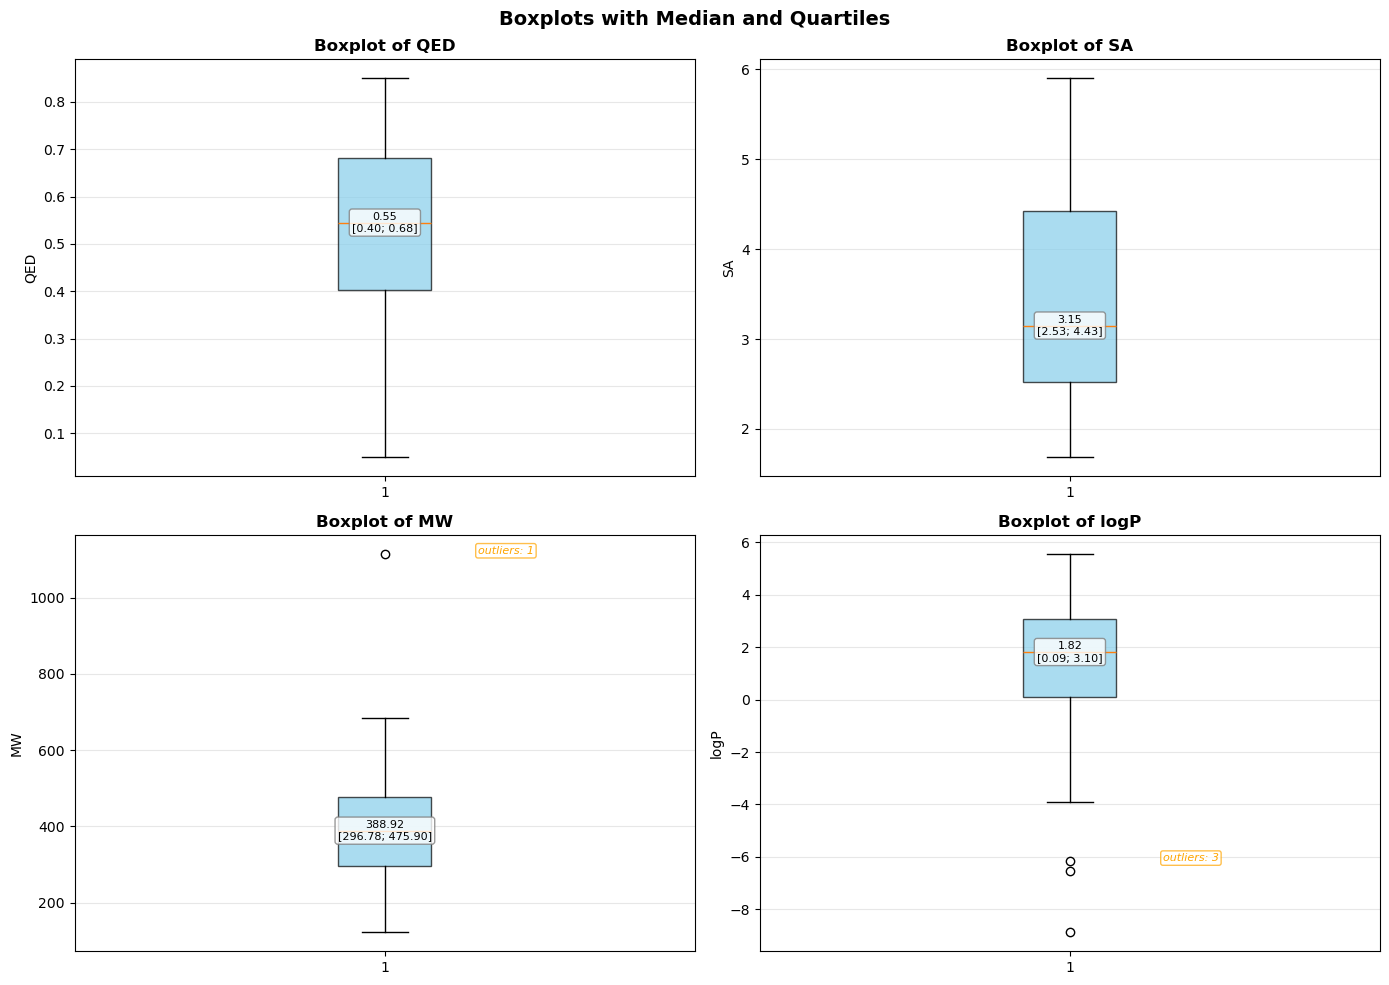

In [33]:
# ============================================
# 1. ВЕРТИКАЛЬНЫЕ BOXPLOT С ПОДПИСЯМИ
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # ВАЖНО: берём данные из колонки, а не саму колонку
    subset = df[col].values  # .values преобразует в numpy массив
    
    # Создаём boxplot
    bp = axes[i].boxplot(subset, vert=True, patch_artist=True,
                          boxprops=dict(facecolor='skyblue', alpha=0.7))
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col, fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)
    
    # Расчёт статистик (используем исходные данные из DataFrame)
    data_series = df[col]
    q1 = data_series.quantile(0.25)
    median = data_series.quantile(0.5)
    q3 = data_series.quantile(0.75)
    
    # Позиция для подписи
    y = median
    x = 1
    
    # Добавляем подпись с рамкой
    axes[i].text(
        x,
        y,
        f"{median:.2f}\n[{q1:.2f}; {q3:.2f}]",
        ha="center",
        va="center",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="gray",
            alpha=0.8
        )
    )
    
    # Добавляем информацию о выбросах
    if len(bp['fliers']) > 0 and len(bp['fliers'][0].get_ydata()) > 0:
        outliers = bp['fliers'][0].get_ydata()
        axes[i].text(
            x + 0.15, 
            outliers[0],
            f'outliers: {len(outliers)}', 
            fontsize=8, 
            color='orange', 
            style='italic',
            bbox=dict(
                boxstyle="round,pad=0.2",
                fc="white",
                ec="orange",
                alpha=0.7
            )
        )

plt.suptitle('Boxplots with Median and Quartiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

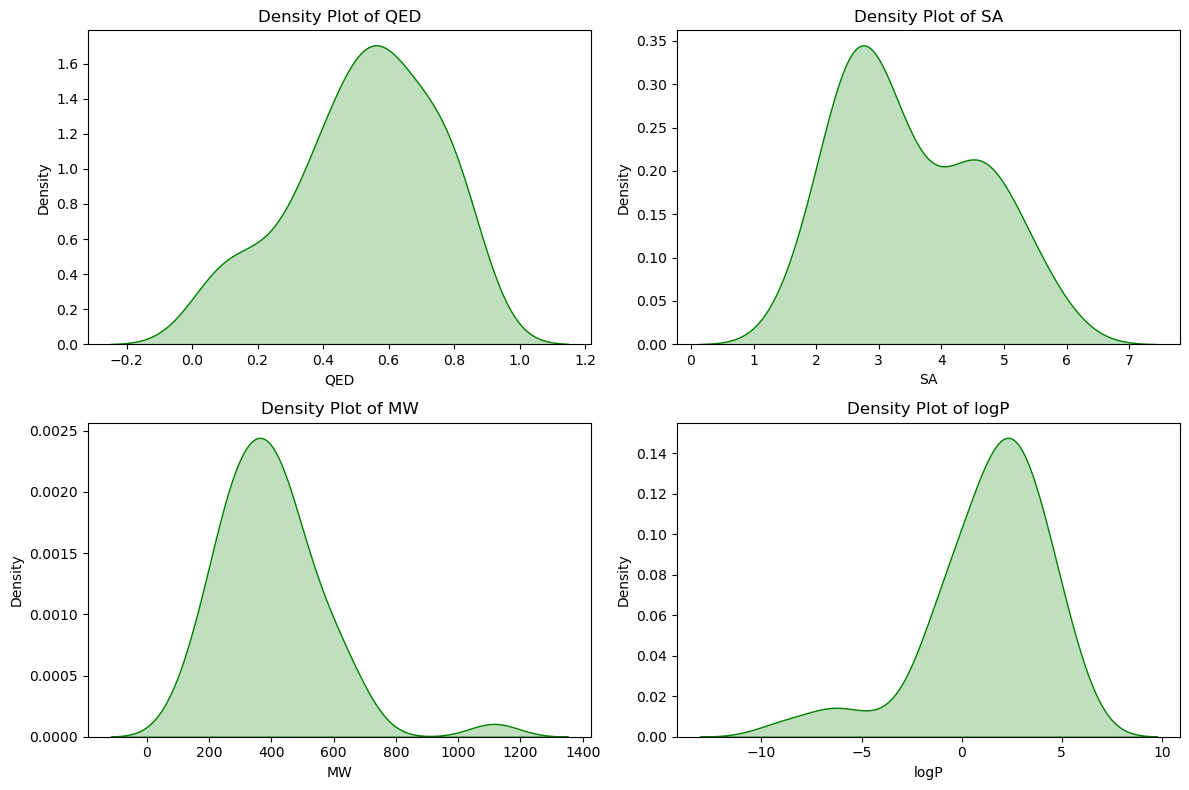

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.kdeplot(df[col], fill=True, ax=axes[i], color='green')
    axes[i].set_title(f'Density Plot of {col}')
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()